In [1]:
import pandas as pd
from transformers import pipeline
import torch
import os
OUTPUT_RAW_DIR = "data/raw"
OUTPUT_PROCESSED_DIR = "data/processed"
MAX_LENGTH = 128
EWMA_SPAN = 5
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"正在使用设备: {DEVICE}")

tuned_sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="./fine_tuned_sentiment_model_soft",  # 微调模型路径
    device=DEVICE,
    dtype=torch.float16 if DEVICE != "cpu" else None
)

def get_tuned_sentiment_score(text):
    """
    调用微调模型计算情绪分数（无阈值过滤）。
    返回 [-1, 1] 范围内的真实置信度分数。
    """
    if pd.isna(text) or not isinstance(text, str) or not text.strip():
        return 0.0
    
    try:
        result = tuned_sentiment_pipeline(text, truncation=True, max_length=MAX_LENGTH)[0]
        label = result['label']
        score = result['score']
        
        # 将模型输出转换为 -1 到 1 的分数
        # Positive 为正向，返回正数；Negative 为负向，返回负数
        final_score = score if label == 'Positive' else -score
        
        return round(final_score, 4)
        
    except Exception as e:
        print(f"情感分析出错: {str(text)[:30]}... → {e}")
        return 0.0
        
def compute_daily_sentiment(df_stock, stock_name):
    if df_stock.empty:
        print(f"{stock_name} 无数据")
        return pd.DataFrame(columns=[
            'pos_sentiment', 'neg_sentiment', 'net_sentiment',
            'topic_count', 'pos_heat', 'neg_heat', 'total_heat'
        ])

    df_stock = df_stock.copy()
    df_stock['date'] = pd.to_datetime(df_stock['date'], errors='coerce')
    df_stock = df_stock.dropna(subset=['date']).sort_values('date')

    grouped = df_stock.groupby('date')
    results = []

    for date, group in grouped:
        group = group.copy()
        group['score'] = group['keyword'].apply(get_tuned_sentiment_score)

        total_heat = group['hot_value'].sum()
        if total_heat <= 0:
            results.append({
                'date': date,
                'pos_sentiment': 0.0,
                'neg_sentiment': 0.0,
                'net_sentiment': 0.0,
                'topic_count': len(group),
                'pos_heat': 0.0,
                'neg_heat': 0.0,
                'total_heat': 0.0
            })
            continue

        # 正面部分
        pos_mask = group['score'] > 0
        pos_heat = group.loc[pos_mask, 'hot_value'].sum()
        if pos_heat > 0:
            pos_sentiment = (group.loc[pos_mask, 'score'] * group.loc[pos_mask, 'hot_value']).sum() / pos_heat
        else:
            pos_sentiment = 0.0

        # 负面部分（取绝对值，数值越大越负面）
        neg_mask = group['score'] < 0
        neg_heat = group.loc[neg_mask, 'hot_value'].sum()
        if neg_heat > 0:
            neg_sentiment = (group.loc[neg_mask, 'score'].abs() * group.loc[neg_mask, 'hot_value']).sum() / neg_heat
        else:
            neg_sentiment = 0.0

        # 净情绪
        net_sentiment = (group['score'] * group['hot_value']).sum() / total_heat

        results.append({
            'date': date,
            'pos_sentiment': round(pos_sentiment, 4),
            'neg_sentiment': round(neg_sentiment, 4),
            'net_sentiment': round(net_sentiment, 4),
            'topic_count': len(group),
            'pos_heat': pos_heat,
            'neg_heat': neg_heat,
            'total_heat': total_heat
        })

    df_daily = pd.DataFrame(results).set_index('date').sort_index()

    # 对三个情绪指标都做 EWMA 平滑
    for col in ['pos_sentiment', 'neg_sentiment', 'net_sentiment']:
        df_daily[f'{col}_smooth'] = df_daily[col].ewm(span=EWMA_SPAN, adjust=False).mean().round(4)

    print(f"{stock_name}: {len(df_daily)} 天，正/负/净情绪已计算")
    return df_daily



# 读取数据
df_tencent = pd.read_csv(os.path.join(OUTPUT_RAW_DIR, "tencent.csv"), encoding="utf-8-sig")
df_alibaba = pd.read_csv(os.path.join(OUTPUT_RAW_DIR, "alibaba.csv"), encoding="utf-8-sig")
df_xiaomi  = pd.read_csv(os.path.join(OUTPUT_RAW_DIR, "xiaomi.csv"),  encoding="utf-8-sig")

# 计算
sent_tencent = compute_daily_sentiment(df_tencent, "腾讯")
sent_alibaba = compute_daily_sentiment(df_alibaba, "阿里")
sent_xiaomi  = compute_daily_sentiment(df_xiaomi,  "小米")

# 对三套情绪指标都保留4位小数
for df in [sent_tencent, sent_alibaba, sent_xiaomi]:
    for col in ['pos_sentiment', 'neg_sentiment', 'net_sentiment',
                'pos_sentiment_smooth', 'neg_sentiment_smooth', 'net_sentiment_smooth']:
        if col in df.columns:
            df[col] = df[col].round(4)

# ===================== 合并成最终的 daily_sentiment.csv =====================
# 列名格式：pos_tencent / neg_tencent / net_tencent 等

merged = pd.concat([
    # 腾讯
    sent_tencent['pos_sentiment_smooth'].rename('pos_tencent'),
    sent_tencent['neg_sentiment_smooth'].rename('neg_tencent'),
    sent_tencent['net_sentiment_smooth'].rename('net_tencent'),
    
    # 阿里
    sent_alibaba['pos_sentiment_smooth'].rename('pos_alibaba'),
    sent_alibaba['neg_sentiment_smooth'].rename('neg_alibaba'),
    sent_alibaba['net_sentiment_smooth'].rename('net_alibaba'),
    
    # 小米
    sent_xiaomi['pos_sentiment_smooth'].rename('pos_xiaomi'),
    sent_xiaomi['neg_sentiment_smooth'].rename('neg_xiaomi'),
    sent_xiaomi['net_sentiment_smooth'].rename('net_xiaomi'),
], axis=1)

# 保存合并后的文件
merged.to_csv(
    os.path.join(OUTPUT_PROCESSED_DIR, "daily_sentiment.csv"),
    encoding="utf-8-sig",
    na_rep='NaN',
    index=True
)

# 同时保存三只股票的详细情绪文件
sent_tencent.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_tencent.csv"),
                    encoding="utf-8-sig", na_rep='NaN', index=True)
sent_alibaba.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_alibaba.csv"),
                    encoding="utf-8-sig", na_rep='NaN', index=True)
sent_xiaomi.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_xiaomi.csv"),
                   encoding="utf-8-sig", na_rep='NaN', index=True)

print("\n已生成三套情绪指标的 CSV 文件：")
print(f"  {OUTPUT_PROCESSED_DIR}/daily_sentiment.csv   （合并文件，含 pos/neg/net）")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_tencent.csv")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_alibaba.csv")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_xiaomi.csv")
print("列名示例：pos_tencent, neg_tencent, net_tencent ...")

# 保存为 CSV（所有结果都用 CSV）
merged.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "daily_sentiment.csv"),
              encoding="utf-8-sig",
              na_rep='NaN',
              index=True)  # 保留 date 作为索引列

# 分别保存个股（也用 CSV）
sent_tencent.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_tencent.csv"),
                    encoding="utf-8-sig",
                    na_rep='NaN',
                    index=True)

sent_alibaba.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_alibaba.csv"),
                    encoding="utf-8-sig",
                    na_rep='NaN',
                    index=True)

sent_xiaomi.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_xiaomi.csv"),
                   encoding="utf-8-sig",
                   na_rep='NaN',
                   index=True)

print("\n完成。所有结果已保存为 CSV 格式：")
print(f"  {OUTPUT_PROCESSED_DIR}/daily_sentiment.csv       (合并表，含三支股票情绪)")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_tencent.csv     (腾讯情绪)")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_alibaba.csv     (阿里情绪)")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_xiaomi.csv      (小米情绪)")
print("缺失日期情绪值为 NaN，未做任何填充。")

正在使用设备: mps


Device set to use mps


腾讯: 192 天，正/负/净情绪已计算
阿里: 162 天，正/负/净情绪已计算
小米: 550 天，正/负/净情绪已计算

已生成三套情绪指标的 CSV 文件：
  data/processed/daily_sentiment.csv   （合并文件，含 pos/neg/net）
  data/processed/sentiment_tencent.csv
  data/processed/sentiment_alibaba.csv
  data/processed/sentiment_xiaomi.csv
列名示例：pos_tencent, neg_tencent, net_tencent ...

完成。所有结果已保存为 CSV 格式：
  data/processed/daily_sentiment.csv       (合并表，含三支股票情绪)
  data/processed/sentiment_tencent.csv     (腾讯情绪)
  data/processed/sentiment_alibaba.csv     (阿里情绪)
  data/processed/sentiment_xiaomi.csv      (小米情绪)
缺失日期情绪值为 NaN，未做任何填充。


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=== 开始情绪-股价相关性分析（正面 / 负面 / 净情绪） ===")

# 加载数据
STOCK_FILE = "data/hk_stocks.csv"
SENTIMENT_FILE = os.path.join("data/processed", "daily_sentiment.csv")

# 1. 读取股价（此时只有交易日）
df_price = pd.read_csv(STOCK_FILE, parse_dates=['date'], date_format='%Y/%m/%d')
df_price['Ticker'] = df_price['Ticker'].astype(str).str.zfill(5)

# 2. 读取情绪（包含每天）
df_sent = pd.read_csv(SENTIMENT_FILE, parse_dates=['date'], index_col='date')
df_sent.index = pd.to_datetime(df_sent.index)

# 股票映射
# pos_tencent / neg_tencent / net_tencent
# pos_alibaba / neg_alibaba / net_alibaba
# pos_xiaomi  / neg_xiaomi  / net_xiaomi
tickers = {
    '00700': ('腾讯', 'tencent'),
    '09988': ('阿里巴巴', 'alibaba'),
    '01810': ('小米', 'xiaomi')
}

# 三种情绪类型
sentiment_types = {
    'pos': '正面情绪',
    'neg': '负面情绪',
    'net': '净情绪'
}

results = []   # 用于后续画图
all_p_values = []
labels = []

for ticker, (name, stock_key) in tickers.items():
    # --- 股价处理 ---
    df_p = df_price[df_price['Ticker'] == ticker].copy().set_index('date').sort_index()
    df_p['ret'] = df_p['close'].pct_change()          # 简单收益率

    print(f"\n{'='*60}")
    print(f"【{name}（{ticker}）】")
    print(f"{'='*60}")

    for sent_key, sent_name in sentiment_types.items():
        sent_col = f"{sent_key}_{stock_key}"   # 例如 pos_tencent

        if sent_col not in df_sent.columns:
            print(f"  警告：缺少列 {sent_col}，跳过 {sent_name}")
            continue

        # 【以价格表（交易日）为基准
        df_m = df_sent[[sent_col]].rename(columns={sent_col: 'sentiment'}).join(
            df_p[['ret']],
            how='right'
        )
        
        # 只对交易日上的缺失情绪做滚动平均填充
        df_m["sentiment"] = df_m["sentiment"].fillna(
            df_m["sentiment"].rolling(window=3, min_periods=1).mean()
        )

        # 清洗无效数据
        df_a = df_m.dropna(subset=['ret', 'sentiment']).copy()

        if len(df_a) < 30:
            print(f"  {sent_name} 数据不足（仅 {len(df_a)} 天），跳过")
            continue

        # 同日相关性
        r_p, p_p = pearsonr(df_a['sentiment'], df_a['ret'])
        r_s, p_s = spearmanr(df_a['sentiment'], df_a['ret'])

        print(f"\n  ▶ {sent_name} vs 日收益率")
        print(f"     同日 Pearson : {r_p:.4f} (p={p_p:.4f})")
        print(f"     同日 Spearman: {r_s:.4f} (p={p_s:.4f})")

        # 滞后相关性（情绪领先股价）
        print("     滞后相关性：")
        for lag in range(0, 6):
            temp = df_a.copy()
            temp['sent_lag'] = temp['sentiment'].shift(lag)
            temp = temp.dropna()

            if len(temp) > 20:
                r, p_value = pearsonr(temp['sent_lag'], temp['ret'])
                
                all_p_values.append(p_value)
                labels.append(f"{name}-{sent_name}-滞后{lag}天")
                
                if p_value < 0.01:
                    sig = "***"
                elif p_value < 0.05:
                    sig = "**"
                elif p_value < 0.1:
                    sig = "*"
                else:
                    sig = ""

                print(f"       滞后 {lag} 天 → r: {r:.4f} (p={p_value:.4f}) {sig}")

        # 保存结果供后续画图使用
        df_a = df_a.copy()
        df_a['stock'] = name
        df_a['sentiment_type'] = sent_name
        results.append(df_a)

print("\n=== 分析完成！ ===")
print(f"成功分析 {len(results)} 组（股票 × 情绪类型）")

=== 开始情绪-股价相关性分析（正面 / 负面 / 净情绪） ===

【腾讯（00700）】

  ▶ 正面情绪 vs 日收益率
     同日 Pearson : 0.0784 (p=0.1685)
     同日 Spearman: 0.0394 (p=0.4897)
     滞后相关性：
       滞后 0 天 → r: 0.0784 (p=0.1685) 
       滞后 1 天 → r: -0.0090 (p=0.8749) 
       滞后 2 天 → r: 0.0231 (p=0.6870) 
       滞后 3 天 → r: -0.0660 (p=0.2489) 
       滞后 4 天 → r: -0.0564 (p=0.3256) 
       滞后 5 天 → r: -0.0662 (p=0.2491) 

  ▶ 负面情绪 vs 日收益率
     同日 Pearson : -0.0551 (p=0.3335)
     同日 Spearman: -0.0048 (p=0.9324)
     滞后相关性：
       滞后 0 天 → r: -0.0551 (p=0.3335) 
       滞后 1 天 → r: -0.0065 (p=0.9097) 
       滞后 2 天 → r: -0.0355 (p=0.5349) 
       滞后 3 天 → r: 0.0148 (p=0.7967) 
       滞后 4 天 → r: 0.0144 (p=0.8013) 
       滞后 5 天 → r: 0.0187 (p=0.7454) 

  ▶ 净情绪 vs 日收益率
     同日 Pearson : 0.0642 (p=0.2598)
     同日 Spearman: 0.0245 (p=0.6676)
     滞后相关性：
       滞后 0 天 → r: 0.0642 (p=0.2598) 
       滞后 1 天 → r: -0.0026 (p=0.9642) 
       滞后 2 天 → r: 0.0239 (p=0.6764) 
       滞后 3 天 → r: -0.0385 (p=0.5011) 
       滞后 4 天 → r: -0.0252 

In [3]:
import numpy as np

def benjamini_hochberg_fdr(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR 校正，判断假阳性
    """
    p_values = np.array(p_values)
    n = len(p_values)

    # 按 p 值从小到大排序
    sorted_idx = np.argsort(p_values)
    sorted_p = p_values[sorted_idx]

    # 计算 BH 阈值：(i / n) * alpha
    thresholds = (np.arange(1, n + 1) / n) * alpha

    # 找到最大的满足 p <= threshold 的位置
    significant = sorted_p <= thresholds
    if significant.any():
        max_idx = np.where(significant)[0][-1]
        reject = np.zeros(n, dtype=bool)
        reject[sorted_idx[:max_idx + 1]] = True
    else:
        reject = np.zeros(n, dtype=bool)

    # 计算调整后的 p 值
    adjusted_p = np.zeros(n)
    cummin = 1.0
    for i in reversed(range(n)):
        adj = sorted_p[i] * n / (i + 1)
        cummin = min(cummin, adj)
        adjusted_p[sorted_idx[i]] = min(cummin, 1.0)

    return {
        'method': 'Benjamini-Hochberg FDR',
        'alpha': alpha,
        'reject': reject,
        'adjusted_p': adjusted_p,
        'significant_count': int(reject.sum())
    }

result = benjamini_hochberg_fdr(all_p_values, alpha=0.05)

print(f"===== {result['method']} =====")
print(f"总检验次数: {result['alpha']:.2f} 显著性水平下共 {len(all_p_values)} 次检验")
print(f"校正后显著个数: {result['significant_count']}")
print()

print(f"{'标签':<30} {'原始p值':>10} {'调整后p值':>12} {'显著?':>10}")
print("-" * 70)

for label, p, adj_p, sig in zip(labels, all_p_values, result["adjusted_p"], result["reject"]):
    marker = "✅" if sig else "❌"
    print(f"{label:<30} {p:>10.6f} {adj_p:>12.6f} {marker:>10}")

===== Benjamini-Hochberg FDR =====
总检验次数: 0.05 显著性水平下共 54 次检验
校正后显著个数: 12

标签                                   原始p值        调整后p值        显著?
----------------------------------------------------------------------
腾讯-正面情绪-滞后0天                     0.168460     0.505380          ❌
腾讯-正面情绪-滞后1天                     0.874897     0.926362          ❌
腾讯-正面情绪-滞后2天                     0.686957     0.858571          ❌
腾讯-正面情绪-滞后3天                     0.248948     0.609867          ❌
腾讯-正面情绪-滞后4天                     0.325559     0.720312          ❌
腾讯-正面情绪-滞后5天                     0.249087     0.609867          ❌
腾讯-负面情绪-滞后0天                     0.333478     0.720312          ❌
腾讯-负面情绪-滞后1天                     0.909676     0.936077          ❌
腾讯-负面情绪-滞后2天                     0.534912     0.825294          ❌
腾讯-负面情绪-滞后3天                     0.796706     0.896529          ❌
腾讯-负面情绪-滞后4天                     0.801281     0.896529          ❌
腾讯-负面情绪-滞后5天                     0.745429     0.892002        

=== 开始绘制三套情绪分析结果图 ===
1. 滞后相关性柱状图
     Stock Sentiment  Best Lag (days)  Max Pearson
0  Tencent      正面情绪                0       0.0784
1  Tencent      负面情绪                0      -0.0551
2  Tencent       净情绪                0       0.0642
3  Alibaba      正面情绪                5      -0.2109
4  Alibaba      负面情绪                4       0.2011
5  Alibaba       净情绪                5      -0.2152
6   Xiaomi      正面情绪                5      -0.0795
7   Xiaomi      负面情绪                5      -0.0350
8   Xiaomi       净情绪                4      -0.0546


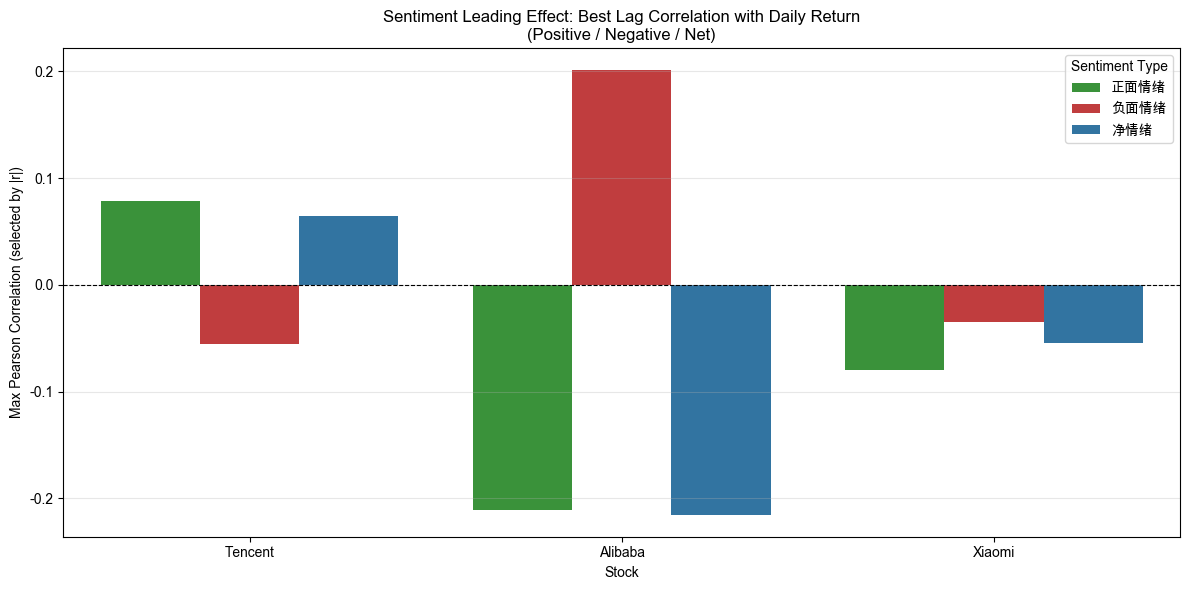


2. 散点图


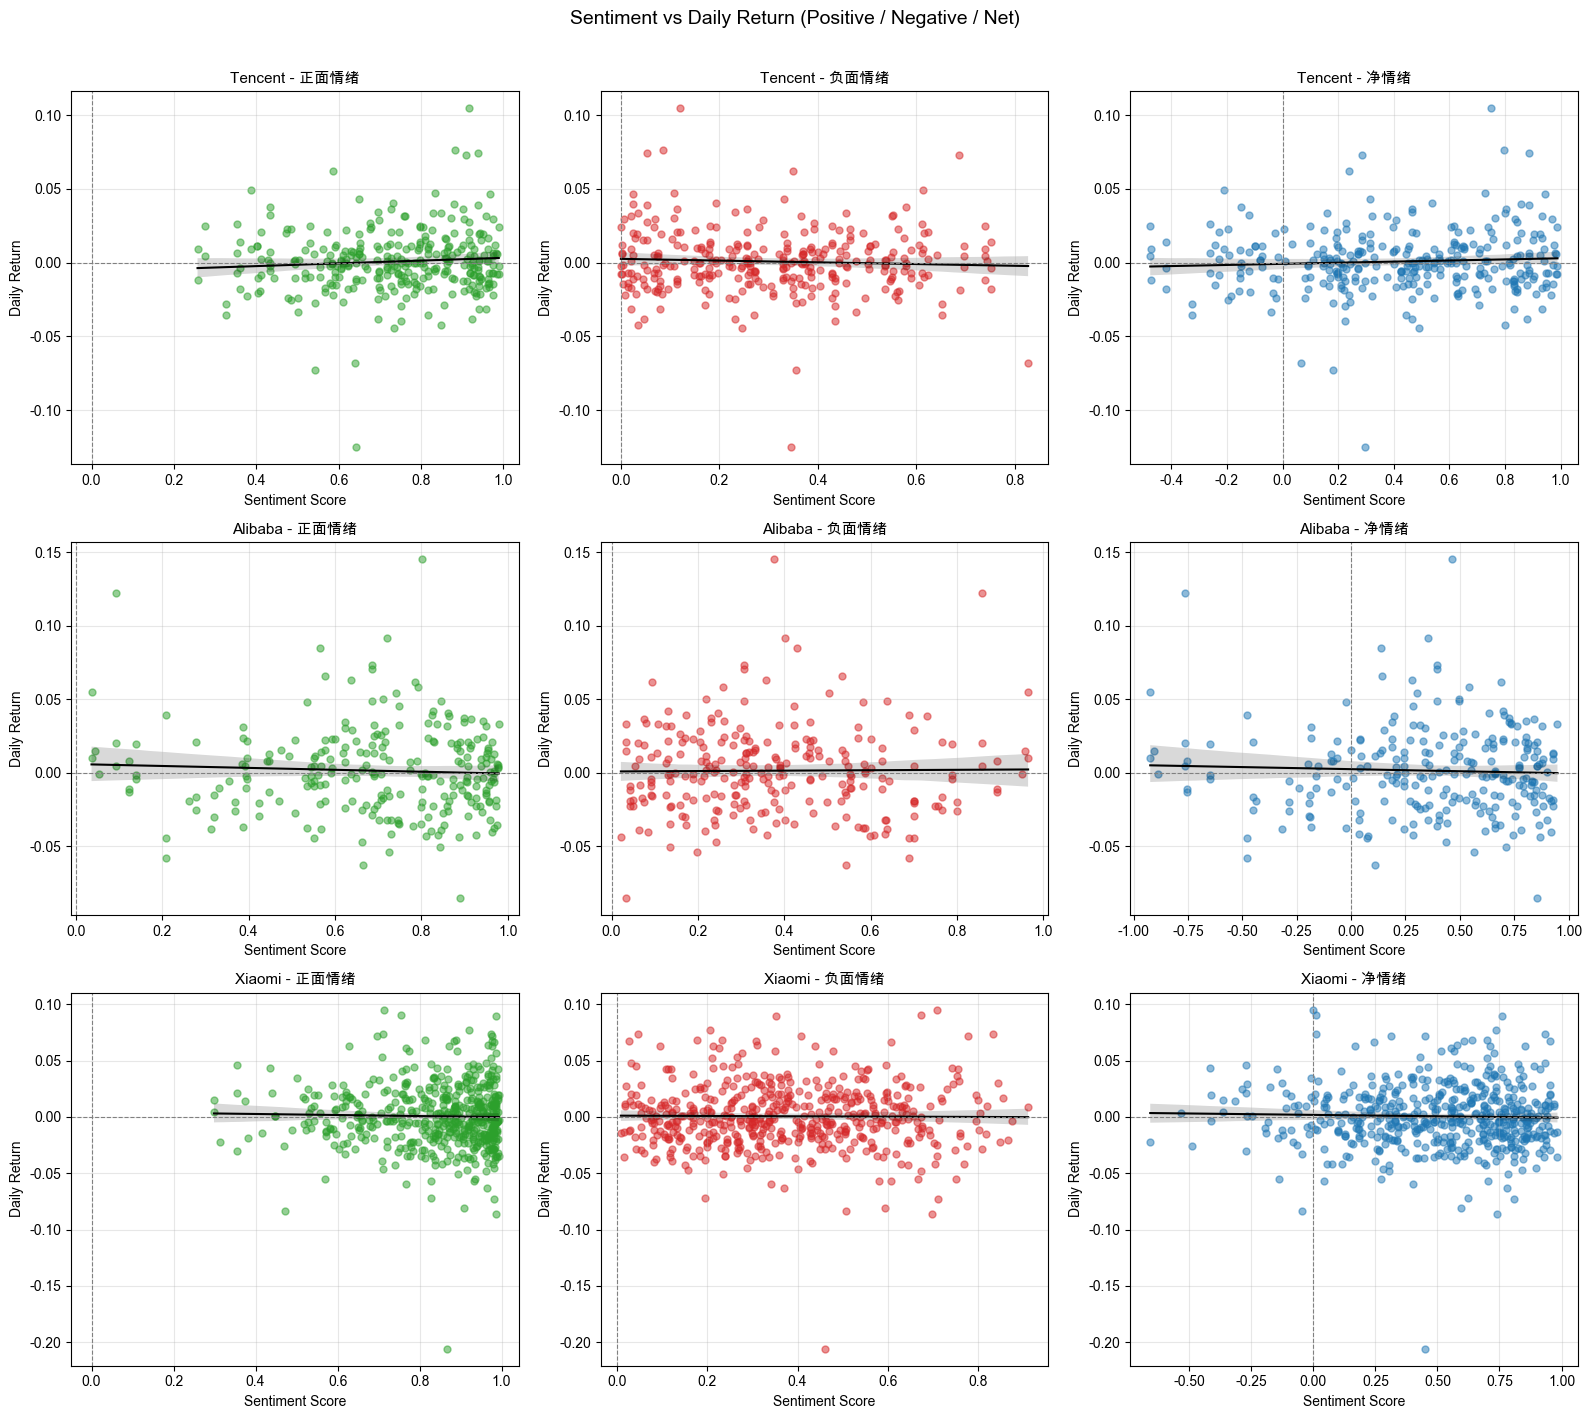


3. 股价与三套情绪时间序列


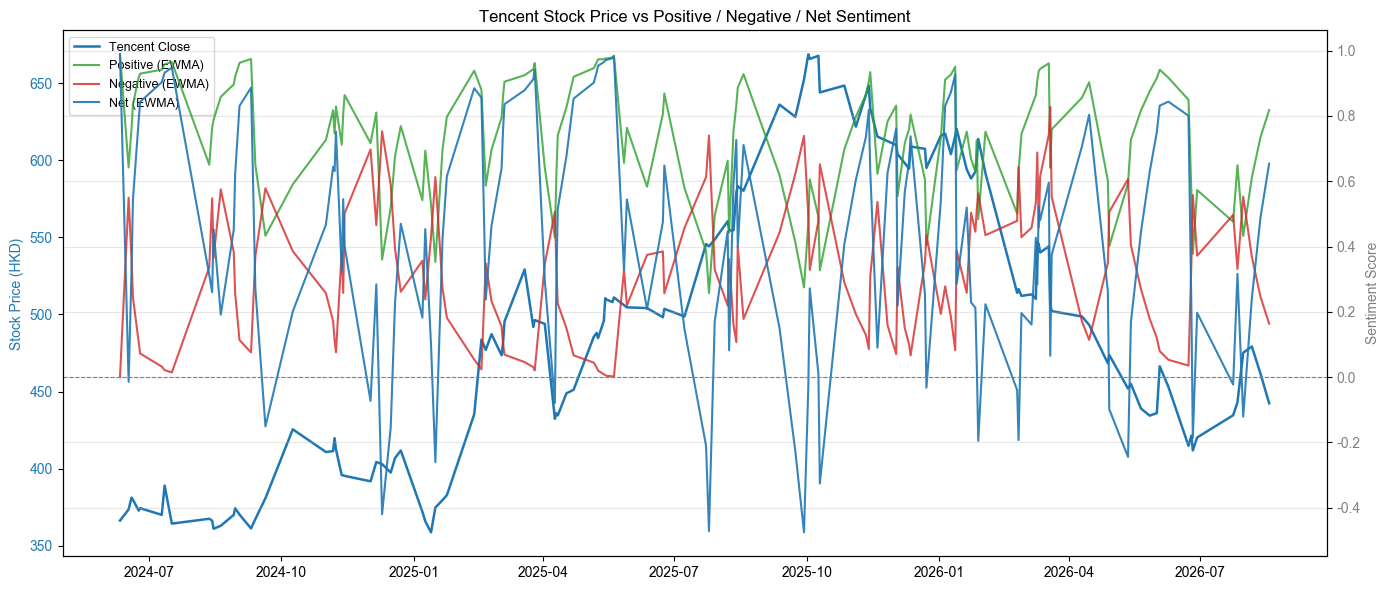

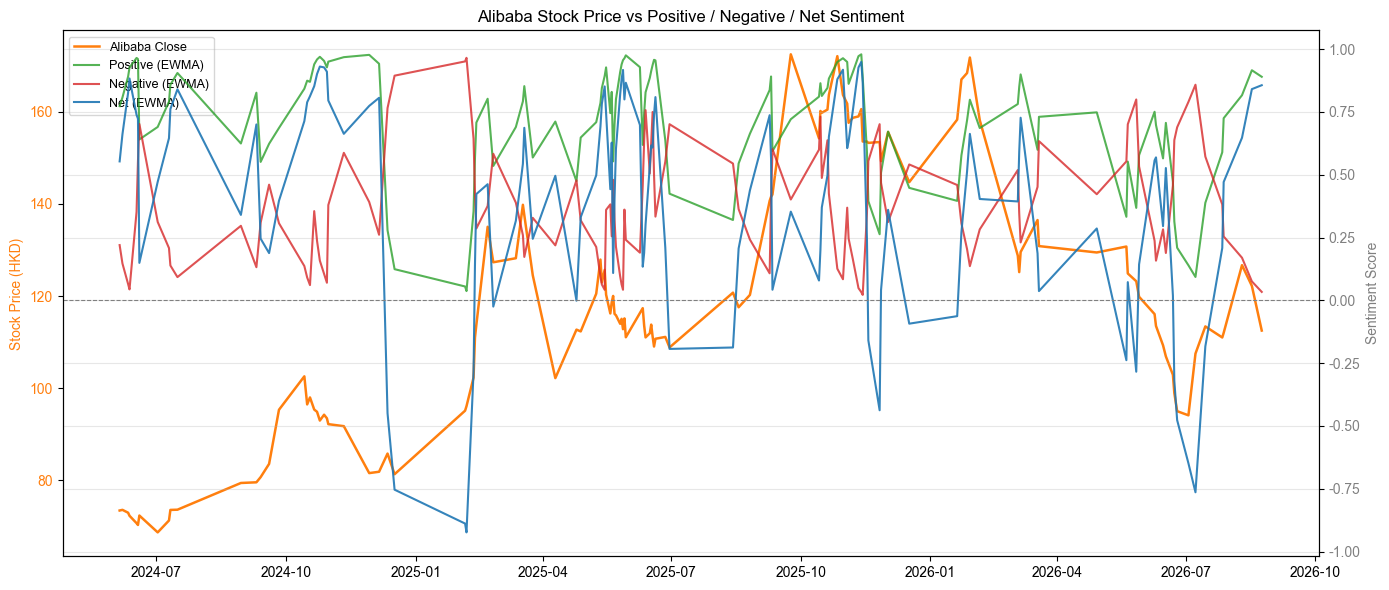

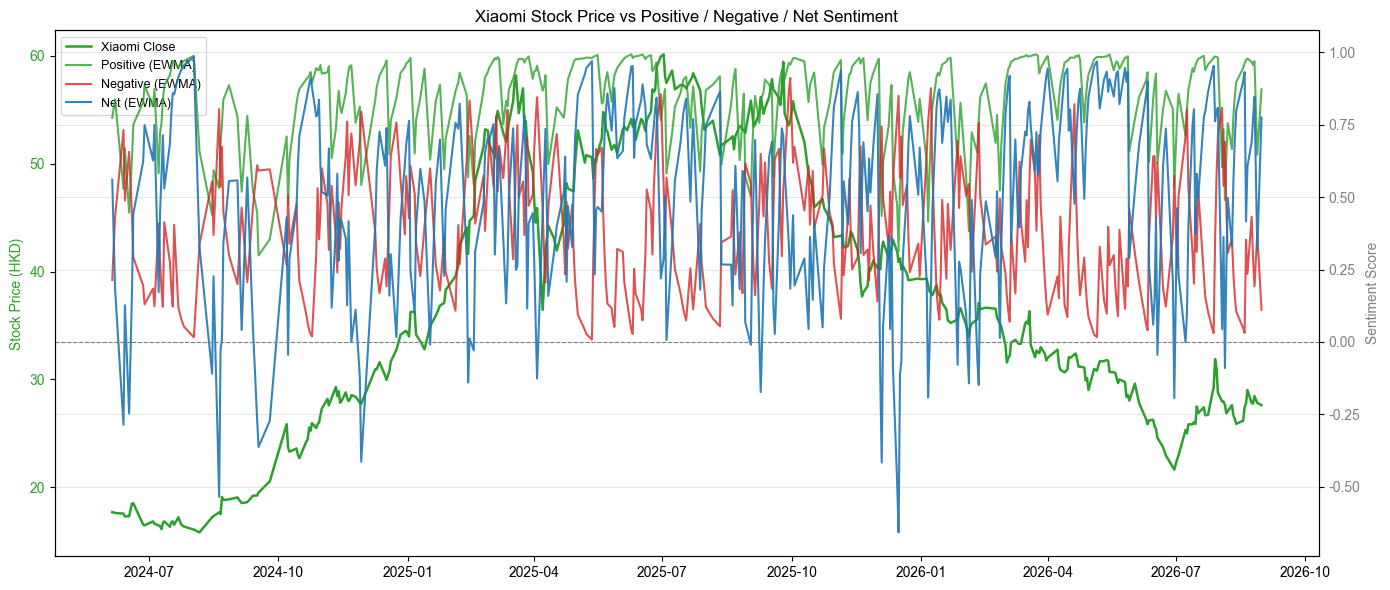


=== 所有图已保存到 data/images/ ===
生成的文件：
  - lag_correlation_pos_neg_net.png
  - scatter_pos_neg_net.png
  - tencent_price_sentiment_pos_neg_net.png
  - alibaba_price_sentiment_pos_neg_net.png
  - xiaomi_price_sentiment_pos_neg_net.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import os

# 设置中文字体（根据你的环境调整）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

os.makedirs("data/images", exist_ok=True)

print("=== 开始绘制三套情绪分析结果图 ===")

if 'results' not in globals() or len(results) == 0:
    raise ValueError("请先运行相关性分析代码，确保 results 列表已生成")

# 统一股票英文名映射
stock_map = {
    '腾讯': 'Tencent',
    '阿里巴巴': 'Alibaba',
    '小米': 'Xiaomi'
}

# 颜色映射
colors = {
    'Tencent': '#1f77b4',
    'Alibaba': '#ff7f0e',
    'Xiaomi': '#2ca02c'
}
sentiment_colors = {
    '正面情绪': '#2ca02c',   # 绿
    '负面情绪': '#d62728',   # 红
    '净情绪': '#1f77b4'      # 蓝
}

# =========================================================
# 1. 滞后相关性柱状图
# =========================================================
print("1. 滞后相关性柱状图")

lag_data = []

for df in results:
    stock_cn = df['stock'].iloc[0]
    stock_en = stock_map.get(stock_cn, stock_cn)
    sent_type = df['sentiment_type'].iloc[0]

    best_abs_r = -np.inf
    best_lag = 0
    best_r = 0

    for lag in range(0, 6):
        temp = df.copy()
        temp['sent_lag'] = temp['sentiment'].shift(lag)
        temp = temp.dropna()
        if len(temp) > 20:
            r, _ = pearsonr(temp['sent_lag'], temp['ret'])
            if abs(r) > best_abs_r:
                best_abs_r = abs(r)
                best_r = r
                best_lag = lag

    lag_data.append({
        'Stock': stock_en,
        'Sentiment': sent_type,
        'Best Lag (days)': best_lag,
        'Max Pearson': round(best_r, 4)
    })

df_lag = pd.DataFrame(lag_data)
print(df_lag)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_lag,
    x='Stock',
    y='Max Pearson',
    hue='Sentiment',
    palette=sentiment_colors
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Sentiment Leading Effect: Best Lag Correlation with Daily Return\n(Positive / Negative / Net)')
plt.ylabel('Max Pearson Correlation (selected by |r|)')
plt.xlabel('Stock')
plt.legend(title='Sentiment Type')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/images/lag_correlation_pos_neg_net.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 2. 散点图 + 回归线（3股票 × 3情绪 = 9张，用子图展示）
# =========================================================
print("\n2. 散点图")

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

idx = 0
for df in results:
    stock_cn = df['stock'].iloc[0]
    stock_en = stock_map.get(stock_cn, stock_cn)
    sent_type = df['sentiment_type'].iloc[0]
    ax = axes[idx]

    sns.regplot(
        data=df,
        x='sentiment',
        y='ret',
        scatter_kws={'alpha': 0.5, 's': 25, 'color': sentiment_colors.get(sent_type, '#9467bd')},
        line_kws={'color': 'black', 'linewidth': 1.5},
        ax=ax
    )
    ax.set_title(f'{stock_en} - {sent_type}', fontsize=11)
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('Daily Return')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    idx += 1

plt.suptitle('Sentiment vs Daily Return (Positive / Negative / Net)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/images/scatter_pos_neg_net.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 3. 股价 + 三套情绪时间序列（每只股票一张图）
# =========================================================
print("\n3. 股价与三套情绪时间序列")

# 重新读取价格数据
df_price = pd.read_csv("data/hk_stocks.csv", parse_dates=['date'], date_format='%Y/%m/%d')
df_price['Ticker'] = df_price['Ticker'].astype(str).str.zfill(5)

ticker_map = {'Tencent': '00700', 'Alibaba': '09988', 'Xiaomi': '01810'}
sent_file_map = {
    'Tencent': 'sentiment_tencent.csv',
    'Alibaba': 'sentiment_alibaba.csv',
    'Xiaomi': 'sentiment_xiaomi.csv'
}

for stock_en, ticker in ticker_map.items():
    # 价格
    df_p = df_price[df_price['Ticker'] == ticker].set_index('date').sort_index()

    # 情绪（从详细文件读取，包含三套平滑情绪）
    sent_path = os.path.join("data/processed", sent_file_map[stock_en])
    if not os.path.exists(sent_path):
        print(f"  跳过 {stock_en}：找不到 {sent_path}")
        continue

    df_s = pd.read_csv(sent_path, parse_dates=['date'], index_col='date')
    df_s.index = pd.to_datetime(df_s.index)

    # 合并
    df_plot = df_p[['close']].join(
        df_s[['pos_sentiment_smooth', 'neg_sentiment_smooth', 'net_sentiment_smooth']],
        how='inner'
    ).dropna()

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # 股价
    ax1.plot(df_plot.index, df_plot['close'], color=colors[stock_en], linewidth=1.8, label=f'{stock_en} Close')
    ax1.set_ylabel('Stock Price (HKD)', color=colors[stock_en])
    ax1.tick_params(axis='y', labelcolor=colors[stock_en])

    # 情绪（右轴）
    ax2 = ax1.twinx()
    ax2.plot(df_plot.index, df_plot['pos_sentiment_smooth'], color='#2ca02c', alpha=0.8, label='Positive (EWMA)')
    ax2.plot(df_plot.index, df_plot['neg_sentiment_smooth'], color='#d62728', alpha=0.8, label='Negative (EWMA)')
    ax2.plot(df_plot.index, df_plot['net_sentiment_smooth'], color='#1f77b4', alpha=0.9, linewidth=1.5, label='Net (EWMA)')
    ax2.set_ylabel('Sentiment Score', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')

    plt.title(f'{stock_en} Stock Price vs Positive / Negative / Net Sentiment')
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'data/images/{stock_en.lower()}_price_sentiment_pos_neg_net.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n=== 所有图已保存到 data/images/ ===")
print("生成的文件：")
print("  - lag_correlation_pos_neg_net.png")
print("  - scatter_pos_neg_net.png")
print("  - tencent_price_sentiment_pos_neg_net.png")
print("  - alibaba_price_sentiment_pos_neg_net.png")
print("  - xiaomi_price_sentiment_pos_neg_net.png")